## Chapter 07 - Using more variables to make predictions, with Multiple Regression

In this chapter, we will:
- Use the `ols()` function for Multiple regression.
- Use random data to create a histogram and a *p*-value for Multiple Regression.
- Understand how $R^2$ and Adjusted $R^2$ change when we add bogus variables to a model.
- Calculate an *F*-value that compares predictions from a fitted plane to a fitted line.

Since we are using Python, the first thing to do is load in some modules that will help us do math and plot graphs.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf

Matplotlib is building the font cache; this may take a moment.


## Using the `ols()` function for Multiple Regression

If we are going to fit a shape to some data, the the first thing we need to do is aquire some data to fit the shape to. We will use the dataset illustrated in Chapter seven, which has the number of stores, the number of products, and the revenue, for five different companies.

In [2]:
num_stores = np.array([2, 12, 15, 9, 8])
num_products = np.array([1, 9, 7, 8 ,7])
revenue = np.array([3, 12.5, 7, 11, 9])

data = pd.DataFrame({
    "num_stores": num_stores,
    "num_products": num_products,
    "revenue": revenue
})

data

,num_stores,num_products,revenue
0,2,1,3.0
1,12,9,12.5
2,15,7,7.0
3,9,8,11.0
4,8,7,9.0


Now that we have the data all packed up in a data frame, we can pass it to the `ols()` function and then use `fit()` to fit a shape to it. Specifically, because we are using two variables ( `num_stores`, and `num_prodcuts` ) to predic `revenue`, we will fit a plane to the data.

In [3]:
## Do a multiple regression and save the results in mr.plane
## where mr = multiple regression.
mr_plane = smf.ols("revenue ~ num_stores + num_products", data=data)

Now that we have created an ordinary least squares model called `model`, we can fit it to our data...

In [4]:
## Now, fit the model to the data (optimize three parameters, 
## the y-axis intercept, and the coefficients for num_stores and num_products)
mr_results = mr_plane.fit()

Now, like we did in the last tutorial, we can calculate the $R^2$ and it's *p*-value, and a ton of other things, with the `summary()` method.

In [5]:
mr_results.summary()

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/regression/linear_model.py:3158: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  omni, omnipv = cached("omni_normtest", lambda: omni_normtest(self.wresid))


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                revenue   R-squared:                       0.966
Model:                            OLS   Adj. R-squared:                  0.931
Method:                 Least Squares   F-statistic:                     28.13
Date:                Sat, 05 Sep 2026   Prob (F-statistic):             0.0343
Time:                        16:30:06   Log-Likelihood:                -4.6599
No. Observations:                   5   AIC:                             15.32
Df Residuals:                       2   BIC:                             14.15
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        1.8716      1.104      1.695      0.232      -2.879       6.622
num_stores      -0.3743      0.165     -2.264      0.152      -1.086       0.337
num_products     1.5738      0.257      6.122      0.026       0.468       2.680
==============================================================================
Omnibus:                          nan   Durbin-Watson:                   1.383
Prob(Omnibus):                    nan   Jarque-Bera (JB):                0.191
Skew:                           0.145   Prob(JB):                        0.909
Kurtosis:                       2.087   Cond. No.                         31.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The summary tells us the $R^2$ for the plane fit is 0.9657. The corresponding *p*-value for the $R^2$ value is listed as `Prob (F-statistic)` and is equalt to 0.0343. Similarly, the `Adjusted R-squared` value is also quite high at 0.931, suggesting that we have not included a bunch of useless variables to our model.So, in this case, we can reject the Null Hypothesis that Revenue predictions derived from the plane are no different from predictions derived from the man value of the Revenue.

Now, let's talk about the coefficients, the parameter values for the y-axis intercept and the slopes associated with the independent variables (the ones we are using to make predictions), `num_stores` and `num_products`. The coefficients, and related statistics, are in the middle of the output generated by `summary()`.

In [6]:
## summary() returns 3 tables
summary_stuff = mr_results.summary()
## print out the second one, it has everything related to the coefficents
summary_stuff.tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,1.8716,1.104,1.695,0.232,-2.879,6.622
num_stores,-0.3743,0.165,-2.264,0.152,-1.086,0.337
num_products,1.5738,0.257,6.122,0.026,0.468,2.680


Like when we did simple linear regression, the first column gives us the parameter values, the y-axis intercept, 1.8716, the slope for `num_stores`, -0.3743, and the slope for `num_products`, 1.5738. Also, like before, the next two columns, **Std. Error** and **t values**, are not super interesting. However, the second too the last column, **P(>|t|)**, is. It tells us the *p*-value for each parameter testing the Null Hypothesis that the specific value is actually 0.

For example, the *p*-value fro `num_products`is 0.026, which tells us that we can reject the Nul Hypothesis that this parameter is 0. This suggests that if we omitted `num_products` from the regresion, and just do a simple linear regression that only ussed `num_stores` would lead to much worse predictions.

Now that we know how to do a multiple regression in $Python$ and interpret the output, let's learn how we can calculate a *p*-value for the $R^2$ value with a histogram.

## Using random data to create a histogram and a *p*-value for Multiple Regression

Just like we did in the last tutorial, we can calculate a *p*-value for a $R^2$ value with a histogram. The only difference is that now we have to generate random data for more variables.

In [7]:
## Since we are going to generate random data, let's start by picking a seed
np.random.seed(42)

## To generate random datasets, we'll use
## normal distributions. These distributions
## will be based on our observed data, so we 
## need to calculate their estimated means and SD:s.

mean_num_stores = data["num_stores"].mean()
sd_num_stores = data["num_stores"].std(ddof=1)

mean_num_products = data["num_products"].mean()
sd_num_products = data["num_products"].std(ddof=1)

mean_revenue = data["revenue"].mean()
sd_revenue = data["revenue"].std(ddof=1)

## Next, we define the number of random datasets we want to create
num_rand_datasets = 10_000

## And we define the number of data points per dataset
num_datapoints = len(data)

## Create an empty array that is num_rand_datasets long
rand_r_squared = np.empty(num_rand_datasets)

## Here is the loop where we create a bunch of random datasets,
## each with num_datapoint values, fit a multiple regression line
## to the random data, and then calculate and stroe the R-squared values

for i in range(num_rand_datasets):

    ## generate random values for each variable
    rand_num_stores = np.random.normal(loc=mean_num_stores,
                                       scale=sd_num_stores,
                                       size=num_datapoints)

    rand_num_products = np.random.normal(loc=mean_num_products,
                                         scale=sd_num_products,
                                         size=num_datapoints)

    rand_revenue = np.random.normal(loc=mean_revenue,
                                    scale=sd_revenue,
                                    size=num_datapoints)

    ## bundle into a DataFrame
    rand_data = pd.DataFrame({
        "rand_num_stores": rand_num_stores,
        "rand_num_products": rand_num_products,
        "rand_revenue": rand_revenue
    }) 

    ## fit a multiple regression to the random data
    ## and calculate the R-squared
    rand_model = smf.ols("rand_revenue ~ rand_num_stores + rand_num_products", data=rand_data)
    rand_results = rand_model.fit()

    ## save the R-squared value.
    rand_r_squared[i] = rand_results.rsquared

Now, let's draw a histogram of the $R^2$ values with the `histplot()` function.b

np.float64(0.0336)

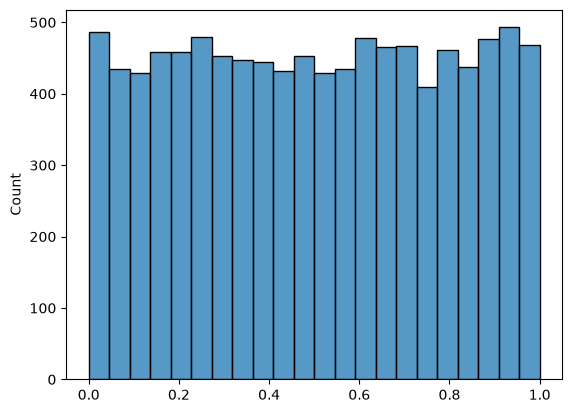

In [9]:
sns.histplot(data=rand_r_squared)

## and calculate the *p*-value as the percentage of "random" $R^$ values greater than
## or equal to the one we got for our original data.

num_greater = np.sum(rand_r_squared >= mr_results.rsquared)
p_value = num_greater /num_rand_datasets
p_value

In [10]:
mr_results.f_pvalue

np.float64(0.034326875310481814)

## Understanding how $R^2$ and Adjusted $R^2$ change when we add bogus variables to a model

In [14]:
## Make a copy of the original data.frame
big_data = data.copy()

## Add a bogus variable to big.data. This variable bogus_1, just has values
## randomly selected from a normal distribution with mean=0 and SD=1.
np.random.seed(1)
big_data["bogus_1"] = np.random.normal(loc=0, scale=1, size=len(data))

big_data

,num_stores,num_products,revenue,bogus_1
0,2,1,3.0,1.624345
1,12,9,12.5,-0.611756
2,15,7,7.0,-0.528172
3,9,8,11.0,-1.072969
4,8,7,9.0,0.865408


Now that we have the data, which now includes a bogus variable, we can perform a multiple regression on it. This means we have to pass the `ols()` function a **formula** that includes all of the possible independent variables: `revenue ~ num_stores + num_products + bogus_1`.

In [16]:
## Do Multiple Regression to predict revenue using all of the 
## remaning columns in big_data
big_model = smf.ols("revenue ~ num_stores + num_products + bogus_1", data=big_data)
big_results = big_model.fit()
big_results.summary()

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/regression/linear_model.py:3158: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  omni, omnipv = cached("omni_normtest", lambda: omni_normtest(self.wresid))


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                revenue   R-squared:                       0.971
Model:                            OLS   Adj. R-squared:                  0.883
Method:                 Least Squares   F-statistic:                     11.06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):              0.217
Time:                        17:00:59   Log-Likelihood:                -4.2608
No. Observations:                   5   AIC:                             16.52
Df Residuals:                       1   BIC:                             14.96
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        2.8076      2.672      1.051      0.484     -31.144      36.759
num_stores      -0.4077      0.230     -1.771      0.327      -3.333       2.518
num_products     1.4793      0.405      3.651      0.170      -3.669       6.628
bogus_1         -0.4482      1.077     -0.416      0.749     -14.135      13.239
==============================================================================
Omnibus:                          nan   Durbin-Watson:                   1.380
Prob(Omnibus):                    nan   Jarque-Bera (JB):                0.721
Skew:                           0.825   Prob(JB):                        0.697
Kurtosis:                       2.139   Cond. No.                         61.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

So when we include the additional variable that is not at all correlated with Revenue, we see that – due to random chance – the value for $R^2$ goes up a little compared to before (0.971 vs 0.966), suggesting that maybe the new prediction will, in general, be better than before. However, the adjusted $R^3$ goes down when we include the uncorrelated variable (0.883 vs 0.931), which suggests that maybe the predictions won't be better.

## Calculate an *F*-value to compare predictions from a fitted plane to a fitted line

As a bonus, let's see if our fitted plane makes significanlty better predictions than a straight line taht just uses `num_stores` to predict `Revenue`. First, we need to do a linear regression so that we have something to compare the multple regression model to.

Straight line predicitons:  0     5.386076
1     9.710970
2    11.008439
3     8.413502
4     7.981013
dtype: float64
SSR(line):  37.26793248945147
Plane predictions:  0     2.696721
1    11.543716
2     7.273224
3    11.092896
4     9.893443
dtype: float64
SSR(Plane):  1.8879781420764998


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/regression/linear_model.py:3158: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  omni, omnipv = cached("omni_normtest", lambda: omni_normtest(self.wresid))


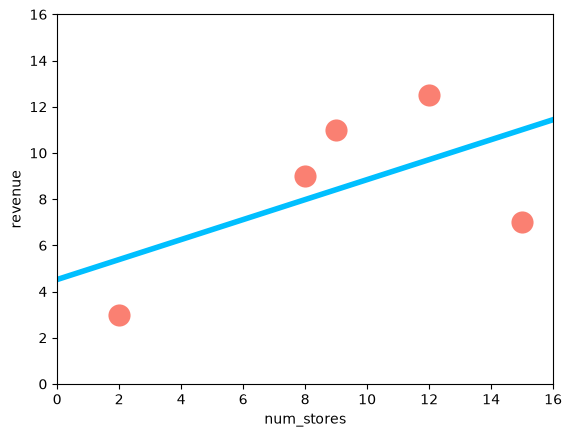

In [21]:
## First create the model object...
model_line = smf.ols("revenue ~ num_stores", data=data)
results_line = model_line.fit()
results_line.summary()

my_plot = sns.scatterplot(x='num_stores', y='revenue', data=data, s=300, color='salmon')
plt.xlim(0,16)
plt.ylim(0,16)
my_plot.axline(xy1=(0, results_line.params.Intercept),
               slope=results_line.params.num_stores,
               color='deepskyblue',
               linestyle='-',
               linewidth=4)

# Let's simultaneously print out the revenue values predicted by the line
print("Straight line predicitons: ", results_line.fittedvalues)
# and the SSR(line)
ssr_line = results_line.ssr
print("SSR(line): ", ssr_line)

# Likewise, we can print out the values predicted by the plane
print("Plane predictions: ", mr_results.fittedvalues)
# and SSR(Plane)
ssr_plane = mr_results.ssr

print("SSR(Plane): ", ssr_plane)

Now that we have SSR(line) and SSR(PLane), we can calculate the *F*-value that compares their predictions.

$$F = \frac{[\textrm{SSR(Simpler)} - \textrm{SSR(Fancier)}] / (p_\textrm{Fancier} - p_\textrm{Simpler})}
    {\textrm{SSR(Fancier)} / (n - p_\textrm{Fancier})}$$

All we have to do is to plug in the values.
- SSR(Simpler) = SSR(line) = 37.268
- SSR(Fancier) = SSR(Plane) = 1.888
- $p_{fancier}$ = 3
- $p_{simpler}$ = 2
- n = 5

In [23]:
F = ((ssr_line - ssr_plane) / (3-2)) / (ssr_plane / (5-3))
F

np.float64(37.479199106047055)

In [25]:
## Lastly, let's convert that *F*-value into a *p*-value, using the `f.cdf()` function.
from scipy.stats import f

# ´f.cdf()` only calculates cumulative probabilities to the *left* of a specified
# x-axis coordinate. Thus, we calculate the area of something happening to the
# *right* of the x-axis coordinate by subtracting the area to the left from 1.
p_value_f = 1 - f.cdf(x=F, dfn=(3 - 2), dfd= (5 - 3))
p_value_f

np.float64(0.025658986278782936)

And the *p*-value 0.026 tells us to reject the Null Hypothesis that there is *no* difference between predictions made with the line-model, as compared to predictions made with the plane-model.